# t-SNE: t-Distributed Stochastic Neighbour Embedding

## Overview

t-SNE converts high-dimensional distances into probabilities and minimises the KL divergence between the high-dimensional and 2D probability distributions. It excels at preserving **local** neighbourhood structure, making nearby points in high dimensions appear near each other in 2D.

**Critical properties and limitations:**

| Property | Implication |
|---|---|
| Preserves local structure | Good for visualising cluster separation |
| Does NOT preserve global structure | Inter-cluster distances are meaningless |
| Non-deterministic | Results vary between runs; always set seed |
| Perplexity-sensitive | Same data produces different plots at different perplexities |
| Cannot embed new points | Must rerun entire algorithm for new data |
| Slow for large n | Use PCA preprocessing; or UMAP for n > 10,000 |

**Perplexity** is loosely the effective number of neighbours considered. It controls the balance between local and global structure. Too low: isolated points; too high: cluster structure dissolves. Range 5–50; always try multiple values.

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(Rtsne)         # Barnes-Hut t-SNE
library(patchwork)

set.seed(42)

n_per <- 120
tsne_data <- bind_rows(
  tibble(nitrate=rnorm(n_per,2,0.5), wq=rnorm(n_per,8,0.6),
         phos=rnorm(n_per,0.3,0.08), turb=rnorm(n_per,3,0.7),
         do2=rnorm(n_per,9.5,0.4),  cond=rnorm(n_per,120,12),
         group="reference"),
  tibble(nitrate=rnorm(n_per,5,0.6), wq=rnorm(n_per,5.5,0.7),
         phos=rnorm(n_per,0.7,0.12), turb=rnorm(n_per,8,1.0),
         do2=rnorm(n_per,7.5,0.6),  cond=rnorm(n_per,200,20),
         group="restored"),
  tibble(nitrate=rnorm(n_per,9,0.8), wq=rnorm(n_per,2.5,0.7),
         phos=rnorm(n_per,1.6,0.2),  turb=rnorm(n_per,18,2.0),
         do2=rnorm(n_per,5.0,0.8),  cond=rnorm(n_per,350,35),
         group="degraded")
)

X      <- tsne_data %>% select(-group) %>% scale()
groups <- tsne_data$group
cat(sprintf("%d observations × %d features\n", nrow(X), ncol(X)))

Warning message:
"package 'Rtsne' was built under R version 4.4.3"


Warning message:
"package 'patchwork' was built under R version 4.4.3"


360 observations × 6 features


---

## Fit t-SNE

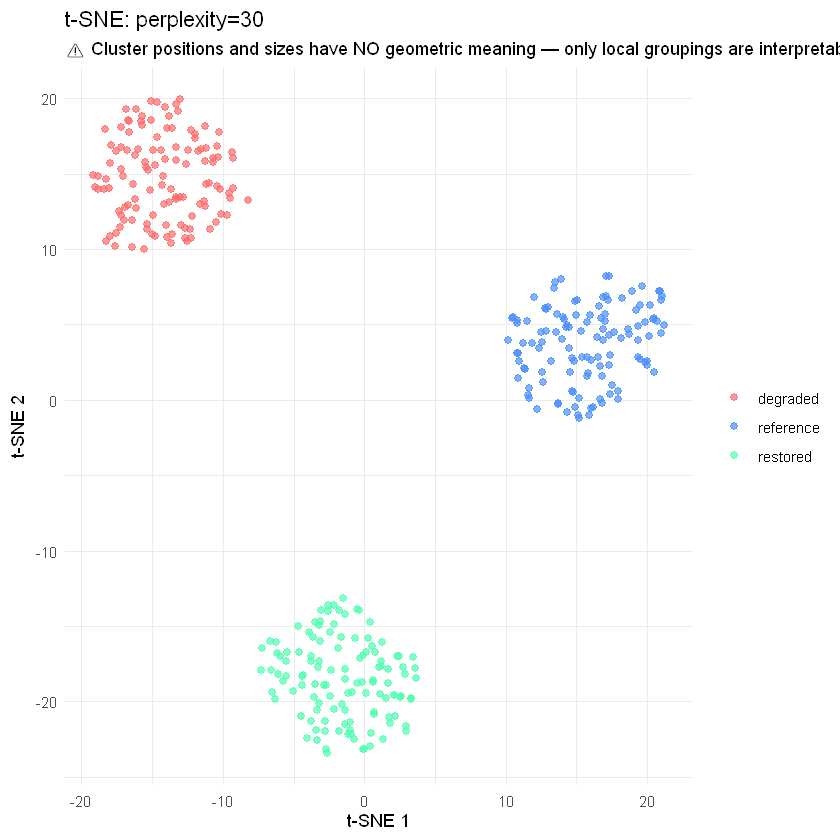

In [4]:
# Best practice: PCA first to reduce noise, then t-SNE on PC scores
pca_scores <- prcomp(X, center=FALSE)$x[, 1:4]  # 4 PCs cover ~95% variance

tsne_fit <- Rtsne::Rtsne(
  pca_scores,
  dims            = 2,
  perplexity      = 30,      # try: 5, 10, 30, 50
  max_iter        = 1500,    # more iterations = better convergence
  theta           = 0.5,     # Barnes-Hut approximation; 0=exact, slower
  eta             = 200,     # learning rate; default usually fine
  check_duplicates = FALSE,
  verbose         = FALSE
)

tsne_df <- tibble(
  tSNE1 = tsne_fit$Y[,1],
  tSNE2 = tsne_fit$Y[,2],
  group = groups
)

ggplot(tsne_df, aes(x=tSNE1, y=tSNE2, color=group)) +
  geom_point(alpha=0.7, size=1.8) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ff6b6b")) +
  labs(title="t-SNE: perplexity=30",
       subtitle="⚠ Cluster positions and sizes have NO geometric meaning — only local groupings are interpretable",
       x="t-SNE 1", y="t-SNE 2", color=NULL) +
  theme_minimal()

---

## Effect of Perplexity

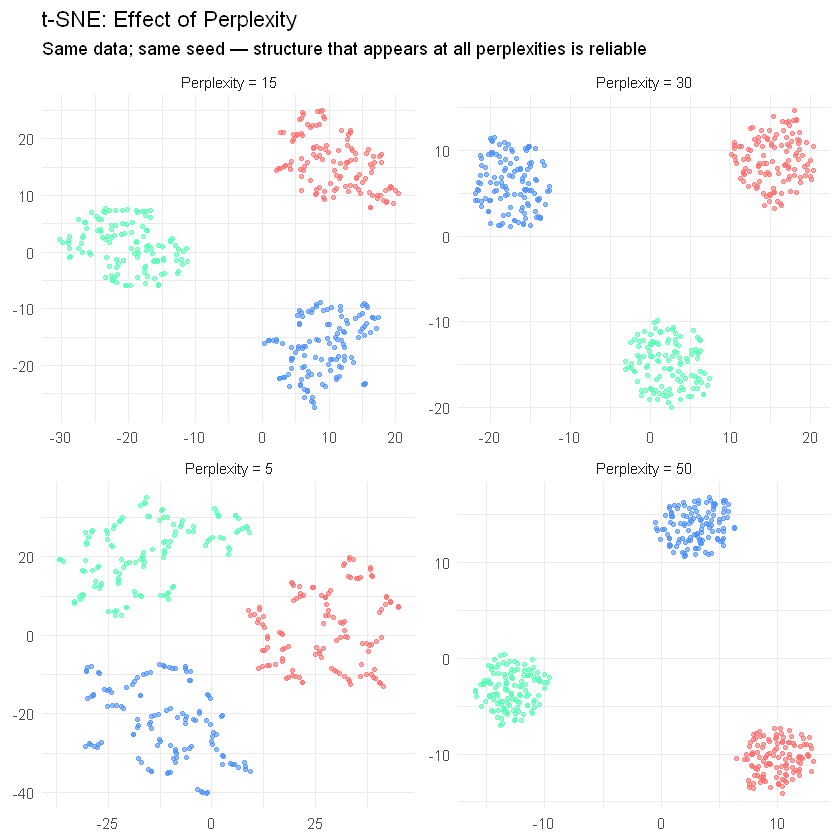

In [5]:
# Perplexity dramatically changes the appearance of the plot
# A single perplexity value can be misleading; always check stability

perp_plots <- map(c(5, 15, 30, 50), function(perp) {
  fit <- Rtsne::Rtsne(pca_scores, dims=2, perplexity=perp,
                       max_iter=1000, theta=0.5,
                       check_duplicates=FALSE, verbose=FALSE)
  tibble(tSNE1=fit$Y[,1], tSNE2=fit$Y[,2],
         group=groups, perplexity=perp)
}) %>% bind_rows()

ggplot(perp_plots, aes(x=tSNE1, y=tSNE2, color=group)) +
  geom_point(alpha=0.6, size=1) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ff6b6b"), guide="none") +
  facet_wrap(~paste("Perplexity =", perplexity), scales="free") +
  labs(title="t-SNE: Effect of Perplexity",
       subtitle="Same data; same seed — structure that appears at all perplexities is reliable",
       x=NULL, y=NULL) +
  theme_minimal()

# Rule of thumb:
# Cluster that appears at perplexity=5 AND perplexity=50 → real structure
# Cluster visible at only one perplexity → likely artefact

---

## Colouring by Feature Values

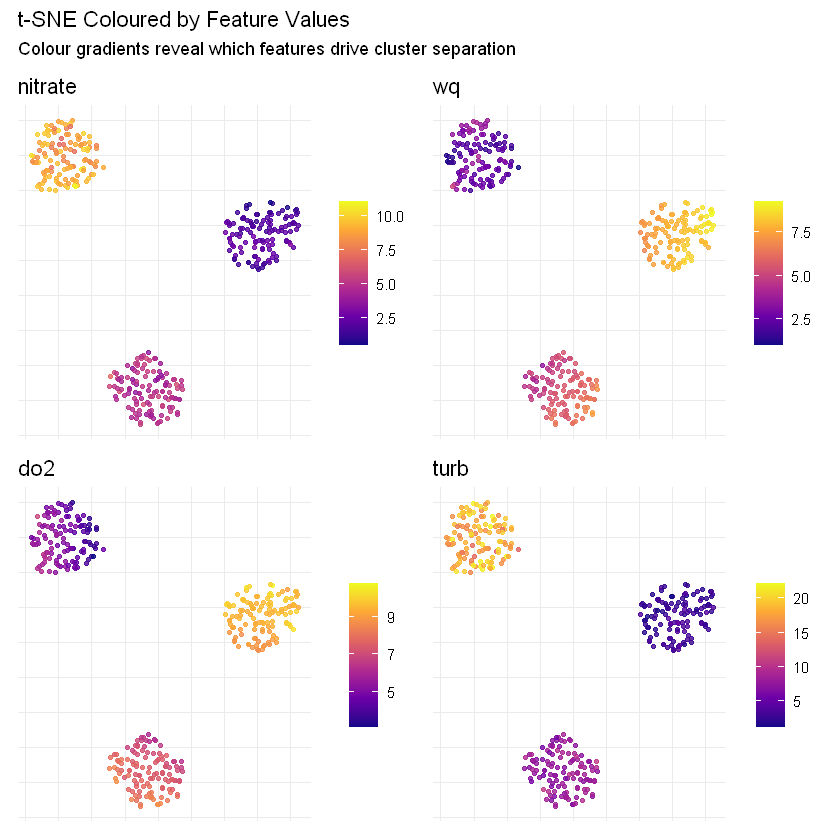

In [6]:
# After fitting t-SNE, colour the embedding by individual feature values
# This reveals which features explain the cluster structure

feature_plots <- c("nitrate","wq","do2","turb") %>%
  map(function(feat) {
    vals <- tsne_data[[feat]]
    tibble(tSNE1=tsne_df$tSNE1, tSNE2=tsne_df$tSNE2, value=vals) %>%
      ggplot(aes(x=tSNE1, y=tSNE2, color=value)) +
      geom_point(size=1.2, alpha=0.8) +
      scale_color_viridis_c(option="plasma") +
      labs(title=feat, x=NULL, y=NULL, color=NULL) +
      theme_minimal() +
      theme(axis.text=element_blank(), axis.ticks=element_blank())
  })

wrap_plots(feature_plots, ncol=2) +
  plot_annotation(
    title="t-SNE Coloured by Feature Values",
    subtitle="Colour gradients reveal which features drive cluster separation"
  )

---

## Common Pitfalls

**1. Interpreting cluster distances as meaningful**  
The most consequential misuse of t-SNE. Two clusters that appear far apart in the 2D plot may be neighbours in the original space. Two clusters appearing close may be distant. Never report "cluster A is more similar to B than to C" based on visual proximity in a t-SNE plot.

**2. Using a single perplexity value**  
Perplexity fundamentally changes the structure that appears. A cluster visible only at perplexity=5 may be an artefact of over-emphasis on small neighbourhoods. Always produce a panel of at least three perplexity values (5, 30, 50) and report only structure that is consistent across them.

**3. Using cluster sizes in t-SNE plots to infer cluster size in the original data**  
t-SNE expands dense regions and compresses sparse ones to fill the plot area. A visually large cluster is not necessarily a large cluster in the original data. Use cluster assignment counts — not visual area — to report sizes.

**4. Running t-SNE on raw features without PCA preprocessing**  
For high-dimensional data (p > 30), running t-SNE directly on raw features is slow, noisy, and sensitive to uninformative dimensions. Reduce to the principal components covering ~90% of variance first, then apply t-SNE to the PC scores.

**5. Changing random seed to get a "cleaner" plot**  
t-SNE is non-deterministic. Choosing the seed that produces the most visually appealing separation is cherry-picking. Run with 3–5 seeds and verify that cluster structure is consistent. If results change substantially between seeds, the structure is unstable.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*